### import libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### read in csv file and do sense checks

In [14]:
df = pd.read_csv('chocolate_sales.csv')

In [17]:
df.head(20)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
5,Van Tuxwell,India,Smooth Sliky Salty,06/06/2022,"$5,376.00",38
6,Oby Sorrel,UK,99% Dark & Pure,25/01/2022,"$13,685.00",176
7,Gunar Cockshoot,Australia,After Nines,24/03/2022,"$3,080.00",73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,20/04/2022,"$3,990.00",59
9,Brien Boise,Australia,99% Dark & Pure,04/07/2022,"$2,835.00",102


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [20]:
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [21]:
df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [22]:
df.describe()

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


### data cleaning

In [25]:
df['Date'] = pd.to_datetime(df['Date'],format='%d/%m/%Y')

In [26]:
df.dtypes

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                   object
Boxes Shipped             int64
dtype: object

In [33]:
df['Amount'] = df['Amount'].str.replace('$','').str.replace(',','').astype('float')

/var/folders/05/p_l3330s4tzbx37pwwg04_hw0000gn/T/ipykernel_2615/1545349315.py:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['Amount'] = df['Amount'].str.replace('$','').str.replace(',','').astype('float')


In [34]:
df.dtypes

Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dtype: object

In [35]:
df.describe()

,Amount,Boxes Shipped
count,3282.000000,3282.000000
mean,6030.338775,164.666971
std,4393.980200,124.024736
min,7.000000,1.000000
25%,2521.495000,71.000000
50%,5225.500000,137.000000
75%,8556.842500,232.000000
max,26170.950000,778.000000


### Exploratory data analysis

In [ ]:
# mean, median

In [36]:
np.mean(df['Amount'])

6030.338775137113

In [37]:
np.median(df['Boxes Shipped'])

137.0

In [40]:
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

In [45]:
country_sales.map('{:,.2f}'.format)

Country
Australia      3,646,444.35
UK             3,365,388.90
India          3,343,730.83
USA            3,313,858.09
Canada         3,078,495.65
New Zealand    3,043,654.04
Name: Amount, dtype: object

In [49]:
# top products by total sales
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

In [53]:
top_products.map('£{:,.2f}'.format)

Product
Smooth Sliky Salty      £1,120,201.09
50% Dark Bites          £1,087,659.35
White Choc              £1,054,257.00
Peanut Butter Cubes     £1,036,591.09
Eclairs                   £996,947.96
99% Dark & Pure           £960,033.45
85% Dark Bars             £955,268.24
Organic Choco Syrup       £945,345.73
Spicy Special Slims       £938,131.69
Mint Chip Choco           £904,989.55
Almond Choco              £890,454.65
Manuka Honey Choco        £885,208.03
Milk Bars                 £866,273.62
Raspberry Choco           £845,388.41
After Nines               £837,215.67
Fruit & Nut Bars          £829,278.96
Orange Choco              £824,070.85
Drinking Coco             £822,245.57
Baker's Choco Chips       £799,085.67
Choco Coated Almonds      £773,062.91
Caramel Stuffed Bars      £742,516.15
70% Dark Bites            £677,346.22
Name: Amount, dtype: object

### matplotlib

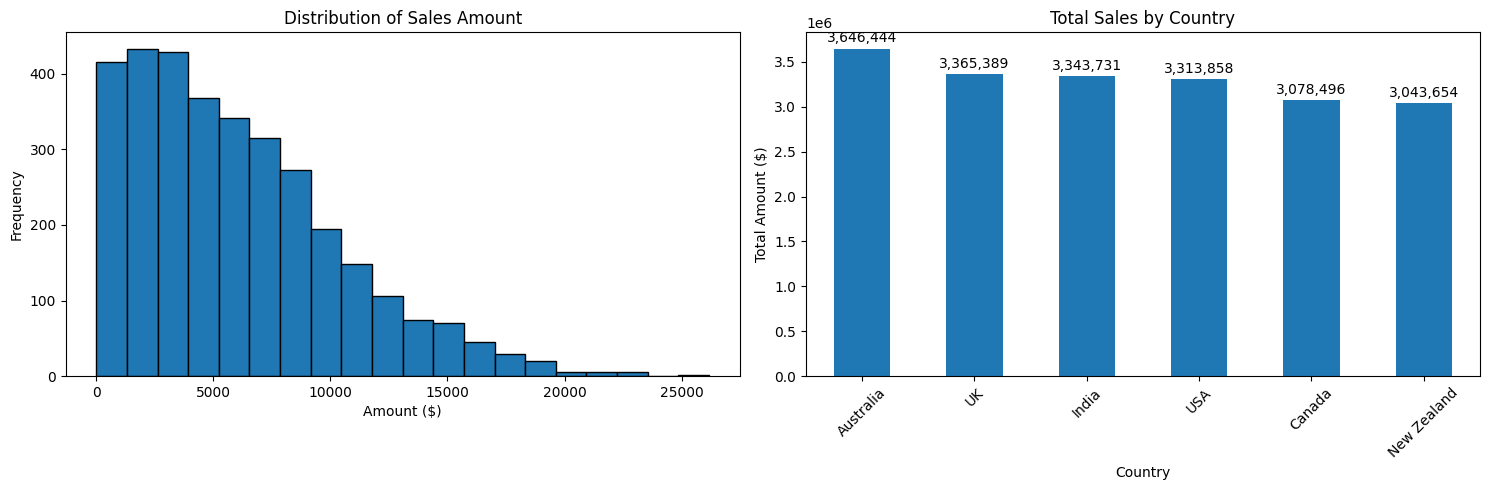

In [61]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=20, edgecolor='black')
plt.title('Distribution of Sales Amount')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
bars = country_sales.plot(kind='bar', ax=plt.gca())  # Get current axes
plt.title('Total Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)

# Add data labels only to bar chart
for i, v in enumerate(country_sales):
    plt.text(i, v + v*0.01, '{:,.0f}'.format(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### seaborn

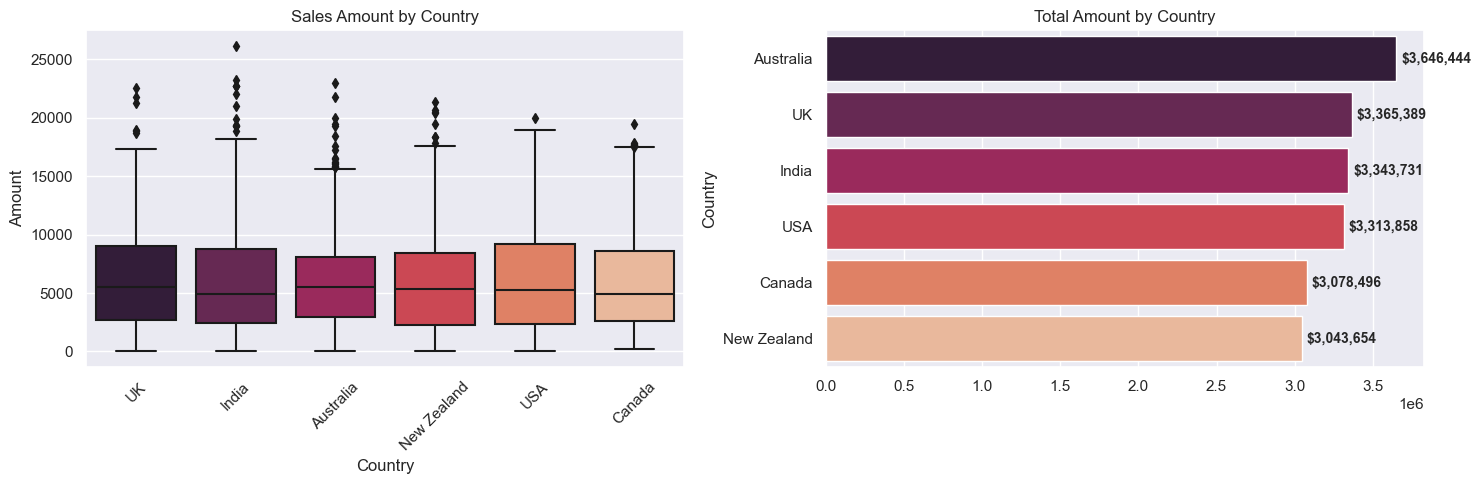

In [64]:
sns.set_theme(
    style="darkgrid",      
    palette="rocket",       
)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Country', y='Amount', ax=axs[0])
axs[0].set_title('Sales Amount by Country')
axs[0].tick_params(axis='x', rotation=45)

# Total Amount per Country
amount_sum = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
countplot = sns.barplot(x=amount_sum.values, y=amount_sum.index, ax=axs[1], palette="rocket")
axs[1].set_title('Total Amount by Country')

# Label bars with formatted currency
for p in countplot.patches:
    width = p.get_width()
    axs[1].text(width + width*0.01, p.get_y() + p.get_height()/2., f'${width:,.0f}', 
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

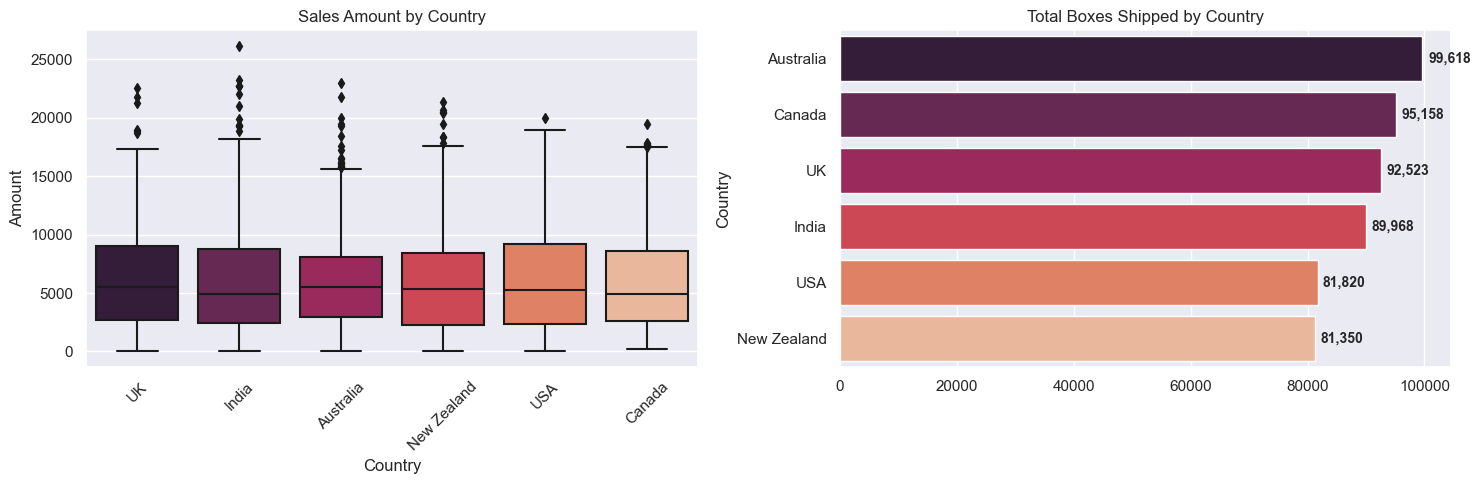

In [65]:
sns.set_theme(
    style="darkgrid",      
    palette="rocket",       
)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Country', y='Amount', ax=axs[0])
axs[0].set_title('Sales Amount by Country')
axs[0].tick_params(axis='x', rotation=45)

# Total Boxes Shipped per Country
boxes_sum = df.groupby('Country')['Boxes Shipped'].sum().sort_values(ascending=False)
countplot = sns.barplot(x=boxes_sum.values, y=boxes_sum.index, ax=axs[1], palette="rocket")
axs[1].set_title('Total Boxes Shipped by Country')

# Label bars with totals
for p in countplot.patches:
    width = p.get_width()
    axs[1].text(width + width*0.01, p.get_y() + p.get_height()/2., f'{int(width):,}', 
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()